# DynSBOD vs DynFD Comparison
Grouped bar charts: insert, delete, and dynamic (mixed event) scenarios.

In [1]:
from chart_utils import *
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter 
import numpy as np
# sns.set_style("whitegrid")

## Load Benchmark Data

In [2]:
ROOT = dynsbod_root

with open(ROOT / "benchmark/dynsbod_results/intermediate/benchmark_metrics.json") as f:
    sbod_insert = json.load(f)
with open(ROOT / "benchmark/dynsbod_results/intermediate_delete/benchmark_metrics.json") as f:
    sbod_delete = json.load(f)
with open(ROOT / "benchmark/dynsbod_results/dynamic_pertuple/benchmark_metrics.json") as f:
    sbod_dynamic = json.load(f)
with open(ROOT / "benchmark/dynfd_results/benchmark_metrics.json") as f:
    dynfd = json.load(f)

BATCH_SIZES = [1, 10, 100, 1000]


In [3]:
# ── helpers ──

EXCLUDED_DATASETS = {"planet", "ncvoter_15"}

def is_excluded(ident):
    """Return True if ident (raw DynSBOD key suffix) refers to an excluded dataset."""
    base = ident
    for suf in ("_events_with_updates", "_final_state", "_baseline"):
        if base.endswith(suf):
            base = base[:-len(suf)]
    return base in EXCLUDED_DATASETS

def avg_ms(runs, key):
    vals = [r[key] for r in runs if isinstance(r.get(key), (int, float))]
    return float(np.mean(vals)) if vals else None

def std_ms(runs, key):
    vals = [r[key] for r in runs if isinstance(r.get(key), (int, float))]
    return float(np.std(vals)) if len(vals) > 1 else 0.0

def sbod_run_std(store, combo_key):
    """Returns std dev of total_ms across runs (in ms), or 0 if unavailable."""
    runs = store.get(combo_key, [])
    return std_ms(runs, "total_ms")

def dynfd_batch_std(dataset_key, batch_size, mode):
    """Returns std dev of total_runtime_ms across DynFD runs (in ms), or 0."""
    if dataset_key is None or dataset_key not in dynfd:
        return 0.0
    entry = dynfd[dataset_key]
    if mode == "insert":
        candidates = [f"batch_{batch_size}", f"insert_batch_{batch_size}"]
    elif mode == "delete":
        candidates = [f"delete_batch_{batch_size}"]
    else:
        candidates = [f"batch_{batch_size}"]
    runs = None
    for sub in candidates:
        if sub in entry:
            runs = entry[sub]
            break
    if runs is None:
        return 0.0
    return std_ms(runs, "total_runtime_ms")

def sbod_time(store, combo_key):
    return avg_ms(store.get(combo_key, []), "total_ms")

TIMEOUT_S  = 14400   # sentinel height for timeout/OOM bars (= actual time limit, 4 h)
TIMEOUT_MS = TIMEOUT_S * 1000   # 14 400 000 ms  (4 h)

def sbod_run_status(store, combo_key):
    """
    Returns ('ok', ms) | ('timeout', None) | ('oom', None) | ('missing', None).
    Runtimes exceeding TIMEOUT_MS are treated as timeout even without an error tag.
    """
    runs = store.get(combo_key, [])
    if not runs:
        return ("missing", None)
    if any("Timeout" in str(r.get("error", "")) for r in runs):
        return ("timeout", None)
    v = avg_ms(runs, "total_ms")
    if v is not None:
        if v > TIMEOUT_MS:
            return ("timeout", None)
        return ("ok", v)
    return ("oom", None)

def dynfd_batch_status(dataset_key, batch_size, mode):
    """
    Returns ('ok', ms) | ('timeout', None) | ('oom', None) | ('missing', None).
    'ok'      – DynFD completed and reported a runtime.
    'timeout' – DynFD ran but exceeded the time limit.
    'oom'     – DynFD ran but produced no parseable output (likely OOM/crash).
    'missing' – DynFD was never run for this dataset / batch combination.
    """
    if dataset_key is None or dataset_key not in dynfd:
        return ("missing", None)
    entry = dynfd[dataset_key]
    if mode == "insert":
        candidates = [f"batch_{batch_size}", f"insert_batch_{batch_size}"]
    elif mode == "delete":
        candidates = [f"delete_batch_{batch_size}"]
    else:
        candidates = [f"batch_{batch_size}"]
    runs = None
    for sub in candidates:
        if sub in entry:
            runs = entry[sub]
            break
    if runs is None:
        return ("missing", None)
    # Check for any timeout error
    if any("Timeout" in str(r.get("error", "")) for r in runs):
        return ("timeout", None)
    # Check for valid runtime
    v = avg_ms(runs, "total_runtime_ms")
    if v is not None:
        return ("ok", v)
    # Runs exist but all None, no timeout marker → likely OOM / crash
    return ("oom", None)

def dynfd_time(dataset_key, batch_size, mode):
    """Convenience wrapper – returns the runtime in ms, or None if unavailable/failed."""
    status, val = dynfd_batch_status(dataset_key, batch_size, mode)
    return val  # None for timeout / oom / missing

def to_dynfd_key(identifier):
    """Map a DynSBOD full-dataset identifier to the DynFD top-level key."""
    if identifier.endswith("_final_state"):
        return f"wikipedia_static_{identifier[:-len('_final_state')]}"
    if identifier.endswith("_events_with_updates"):
        return f"wikipedia_dynamic_{identifier[:-len('_events_with_updates')]}"
    for prefix in ("complete_long_", "complete_"):
        k = prefix + identifier
        if k in dynfd:
            return k
    return None

def display_name(identifier):
    """Short human-friendly label for a DynSBOD identifier."""
    for suf in ("_events_with_updates", "_final_state", "_baseline"):
        if identifier.endswith(suf):
            identifier = identifier[: -len(suf)]
    name = format_dataset_name(identifier)
    # Break at hyphens so long names (e.g. ncvoter-reduced) don't clip bars
    name = name.replace("-", "-\n")
    return name

def fmt_time(secs, pos=None):
    if secs <= 0:   return "0"
    if secs < 1:    return f"{secs*1000:.0f}ms"
    if secs < 3600: return f"{secs:.0f}s"
    return f"{secs/3600:.1f}h"

def dynfd_has_any_data(fd_key, mode):
    """Return True if DynFD has at least one ok or timeout result for this dataset/mode.
    Pure OOM/crash (all None) is treated the same as missing – don't show the dataset."""
    return any(
        dynfd_batch_status(fd_key, bs, mode)[0] in ("ok", "timeout")
        for bs in BATCH_SIZES
    )

# ── colour palette ──
SBOD_COLOR = "#2166AC"
FD_COLORS  = ["#FEE08B", "#FDAE61", "#F46D43", "#D73027"]
BAR_W      = 0.15

BAR_EDGECOLOR = None


In [4]:
def build_legend_handles(rows):
    """Build legend patch list from a list of row-dicts.
    Colour patches per algorithm (ok only); single shared gray entries for TL / OOM.
    """
    handles = []
    sbod_statuses = {r.get("sbod_status", "ok" if r.get("sbod_ms") is not None else "missing")
                     for r in rows}
    if "ok" in sbod_statuses:
        handles.append(mpatches.Patch(color=SBOD_COLOR, label="DynSBOD"))

    has_fd = any(
        s not in (None, "missing")
        for r in rows for s in r.get("dynfd_status", {}).values()
    )
    if has_fd:
        for j, bs in enumerate(BATCH_SIZES):
            statuses = {r["dynfd_status"].get(bs) for r in rows if "dynfd_status" in r}
            if "ok" in statuses:
                handles.append(mpatches.Patch(color=FD_COLORS[j], label=f"DynFD bs={bs}"))

    # Single shared entries for timeout / OOM (gray pattern, algorithm-independent)
    all_statuses = (
        [r.get("sbod_status") for r in rows]
        + [s for r in rows for s in r.get("dynfd_status", {}).values()]
    )
    if "timeout" in all_statuses:
        handles.append(mpatches.Patch(facecolor="lightgray", hatch="///",
            edgecolor="gray", linewidth=0.5, label="Time limit"))
    if "oom" in all_statuses:
        handles.append(mpatches.Patch(facecolor="lightgray", hatch="\\\\",
            edgecolor="gray", linewidth=0.5, label="OOM / TL"))
    return handles


def draw_bars_on_ax(ax, datasets, all_labels, ylabel, title, ylog=True, add_legend=True,
                    show_ytick_labels=True):
    """
    Core bar-drawing routine.  Draws into *ax* using the given global label order.

    datasets:         list of row-dicts with 'label', 'sbod_ms', 'sbod_status',
                      'dynfd_ms', 'dynfd_status'.
    all_labels:       ordered list of all y-tick labels (used for positioning).
    add_legend:       if True, attach a per-axis legend.
    show_ytick_labels if False, hides all y-axis tick labels.
    """
    if not datasets:
        ax.set_visible(False)
        return

    label_idx = {lbl: i for i, lbl in enumerate(all_labels)}
    n = len(all_labels)

    has_fd = any(
        ds["dynfd_status"].get(bs) not in (None, "missing")
        for ds in datasets for bs in BATCH_SIZES
    )
    n_bars  = (1 + len(BATCH_SIZES)) if has_fd else 1
    offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * (BAR_W + 0.01)

    for ds in datasets:
        i = label_idx[ds["label"]]
        sbod_status = ds.get("sbod_status", "ok" if ds["sbod_ms"] is not None else "missing")
        sbod_s = ds["sbod_ms"] / 1000 if ds["sbod_ms"] is not None else None
        if sbod_status == "ok" and sbod_s is not None:
            sbod_err = ds.get("sbod_ms_err", 0) / 1000
            ax.barh(i + offsets[0], sbod_s, height=BAR_W, color=SBOD_COLOR,
                    # xerr=sbod_err if sbod_err else None,
                     capsize=2,
                    # error_kw={"elinewidth": 0.8, "ecolor": "black"}
                    )
        elif sbod_status == "timeout":
            ax.barh(i + offsets[0], TIMEOUT_S, height=BAR_W, color=SBOD_COLOR,
                    hatch="///", edgecolor=BAR_EDGECOLOR, linewidth=0.5, alpha=0.7)
        elif sbod_status == "oom":
            ax.barh(i + offsets[0], TIMEOUT_S, height=BAR_W, color=SBOD_COLOR,
                    hatch="\\\\", edgecolor=BAR_EDGECOLOR, linewidth=0.5, alpha=0.5)
        if has_fd:
            for j, bs in enumerate(BATCH_SIZES):
                status  = ds["dynfd_status"].get(bs, "missing")
                val_ms  = ds["dynfd_ms"].get(bs)
                color   = FD_COLORS[j]
                if status == "ok" and val_ms is not None:
                    fd_err = ds.get("dynfd_ms_err", {}).get(bs, 0) / 1000
                    ax.barh(i + offsets[j + 1], val_ms / 1000, height=BAR_W, color=color,
                            # xerr=fd_err if fd_err else None, 
                            capsize=2,
                            # error_kw={"elinewidth": 0.8, "ecolor": "black"}
                            )
                elif status == "timeout":
                    ax.barh(i + offsets[j + 1], TIMEOUT_S, height=BAR_W, color=color,
                            hatch="///", edgecolor=BAR_EDGECOLOR, linewidth=0.5, alpha=0.7)
                elif status == "oom":
                    ax.barh(i + offsets[j + 1], TIMEOUT_S, height=BAR_W, color=color,
                            hatch="\\\\", edgecolor=BAR_EDGECOLOR, linewidth=0.5, alpha=0.5)

    if ylog:
        ax.set_xscale("log")
    ax.set_yticks(np.arange(n))
    if show_ytick_labels:
        ax.set_yticklabels(all_labels, fontsize=10)
    else:
        ax.set_yticklabels([""] * n)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_xlabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

    # Faint vertical grid lines to help read runtimes for rows far from the x-axis
    ax.xaxis.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)

    if add_legend:
        leg_handles = build_legend_handles(datasets)
        if leg_handles:
            ax.legend(handles=leg_handles, fontsize=8, loc="lower right", framealpha=0.7)

    sns.despine(ax=ax)


def grouped_bar(datasets, ylabel, title, save_name=None, ylog=True, note=None):
    """Stand-alone grouped-bar chart (one chart per call)."""
    if not datasets:
        print(f"No data for: {title}")
        return
    all_labels = [d["label"] for d in datasets]
    fig_h = max(2.5, len(datasets) * 0.45)
    fig, ax = plt.subplots(figsize=(7, fig_h))
    draw_bars_on_ax(ax, datasets, all_labels, ylabel, title, ylog=ylog)
    if note:
        ax.text(0.99, 0.01, note, transform=ax.transAxes, ha="right", va="bottom",
                fontsize=7.5, style="italic", color="gray")
    plt.tight_layout()
    if save_name:
        save_figure(save_name)
    plt.show()


def grouped_bar_combined(insert_rows, delete_rows, ylabel="Total runtime",
                         save_name=None, ylog=True):
    """
    Butterfly chart: delete bars grow leftward on the left panel, insert bars grow
    rightward on the right panel.  Dataset labels appear in the centre column between
    the two panels.  A single shared legend is placed below the figure.
    """
    ins_by_label = {r["label"]: r for r in insert_rows}
    del_by_label = {r["label"]: r for r in delete_rows}
    all_labels_set = list(dict.fromkeys(
        [r["label"] for r in insert_rows] + [r["label"] for r in delete_rows]
    ))

    def sort_key(lbl):
        r = ins_by_label.get(lbl) or del_by_label.get(lbl)
        ms = r.get("sbod_ms") if r else None
        return ms if ms is not None else float("inf")

    all_labels = sorted(all_labels_set, key=sort_key)
    n = len(all_labels)
    fig_h = max(3.0, n * 0.45)

    # Three-column layout: [delete panel | label column | insert panel]
    # Label column is narrow (fixed width fraction via width_ratios)
    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=(7, fig_h))
    gs = GridSpec(1, 3, figure=fig, width_ratios=[5, 1.4, 5], wspace=0.0)
    ax_del   = fig.add_subplot(gs[0])
    ax_label = fig.add_subplot(gs[1])
    ax_ins   = fig.add_subplot(gs[2])

    del_data = [del_by_label[l] for l in all_labels if l in del_by_label]
    ins_data = [ins_by_label[l] for l in all_labels if l in ins_by_label]

    draw_bars_on_ax(ax_del, del_data, all_labels, ylabel,
                    "Delete (full → empty)", ylog=ylog, add_legend=False,
                    show_ytick_labels=False)
    draw_bars_on_ax(ax_ins, ins_data, all_labels, ylabel,
                    "Insert (empty → full)", ylog=ylog, add_legend=False,
                    show_ytick_labels=False)

    # Delete panel grows leftward
    ax_del.invert_xaxis()
    ax_del.tick_params(axis="y", right=True, left=False)
    ax_ins.tick_params(axis="y", right=False, left=True)
    ax_del.spines["right"].set_visible(True)
    ax_del.spines["left"].set_visible(False)
    ax_ins.spines["right"].set_visible(False)
    ax_ins.spines["left"].set_visible(True)

    # Centre label column: plain text labels, no axes visible
    ax_label.set_xlim(0, 1)
    ax_label.set_ylim(-0.5, n - 0.5)
    ax_label.axis("off")
    for i, lbl in enumerate(all_labels):
        ax_label.text(0.5, i, lbl, ha="center", va="center", fontsize=10,
                      transform=ax_label.transData)

    # Single shared legend below the figure
    leg_handles = build_legend_handles(insert_rows + delete_rows)
    if leg_handles:
        fig.legend(handles=leg_handles, loc="lower center",
                   ncol=min(len(leg_handles), 3),
                   fontsize=12, framealpha=0.7,
                   bbox_to_anchor=(0.5, -0.08))

    plt.tight_layout()
    if save_name:
        save_figure(save_name)
    plt.show()


## Chart 1: Insert (empty → full dataset)

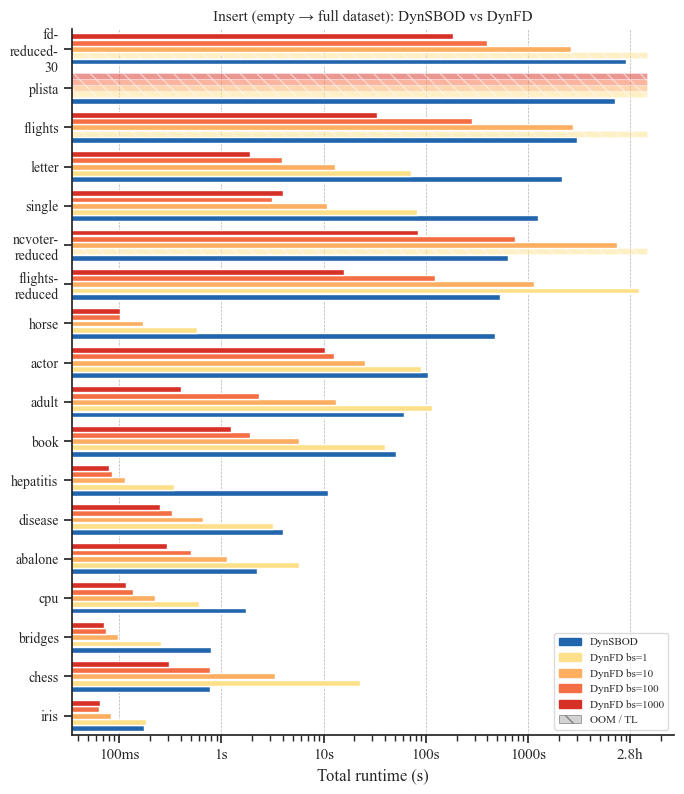


Filtered from INSERT chart (1 dataset(s)):
  ncvoter                                   reason=DynFD not run / only OOM  sbod=timeout  dynfd=[bs=1:oom, bs=10:oom, bs=100:oom, bs=1000:oom]


In [5]:
insert_rows = []
filtered_insert = []   # (ident, reason, sbod_status, dynfd_statuses)

for combo_key in sorted(sbod_insert):
    if not combo_key.startswith("algo0_java0_"):
        continue
    ident = combo_key[len("algo0_java0_"):]

    if any(x in ident for x in ("_first_half", "_second_half", "events_with_updates", "_baseline")):
        continue

    if is_excluded(ident):
        continue

    fd_key = to_dynfd_key(ident)
    sbod_st, sbod_ms = sbod_run_status(sbod_insert, combo_key)
    fd_statuses = {bs: dynfd_batch_status(fd_key, bs, "insert")[0] for bs in BATCH_SIZES}
    fd_times    = {bs: dynfd_batch_status(fd_key, bs, "insert")[1] for bs in BATCH_SIZES}

    # Omit datasets where DynFD was never attempted at all AND DynSBOD has no useful result
    if not dynfd_has_any_data(fd_key, "insert") and sbod_st != "ok":
        filtered_insert.append((display_name(ident), "DynFD not run / only OOM", sbod_st, fd_statuses))
        continue

    if sbod_st == "missing" and all(s == "missing" for s in fd_statuses.values()):
        filtered_insert.append((display_name(ident), "all data missing", sbod_st, fd_statuses))
        continue

    insert_rows.append(dict(
        label        = display_name(ident),
        sbod_ms      = sbod_ms,
        sbod_ms_err  = sbod_run_std(sbod_insert, combo_key),
        sbod_status  = sbod_st,
        dynfd_ms     = fd_times,
        dynfd_ms_err = {bs: dynfd_batch_std(fd_key, bs, "insert") for bs in BATCH_SIZES},
        dynfd_status = fd_statuses,
    ))

insert_rows.sort(key=lambda r: r["sbod_ms"] if r["sbod_ms"] is not None else float("inf"))

grouped_bar(
    insert_rows,
    ylabel    = "Total runtime (s)",
    title     = "Insert (empty → full dataset): DynSBOD vs DynFD",
    save_name = "comparison_insert",
    ylog      = True,
)

if filtered_insert:
    print(f"\nFiltered from INSERT chart ({len(filtered_insert)} dataset(s)):")
    for name, reason, ss, fds in sorted(filtered_insert):
        fd_summary = ", ".join(f"bs={bs}:{s}" for bs, s in fds.items())
        print(f"  {name:40s}  reason={reason}  sbod={ss}  dynfd=[{fd_summary}]")
else:

    print("\nNo datasets filtered from INSERT chart.")

## Chart 2: Delete (full dataset → empty)

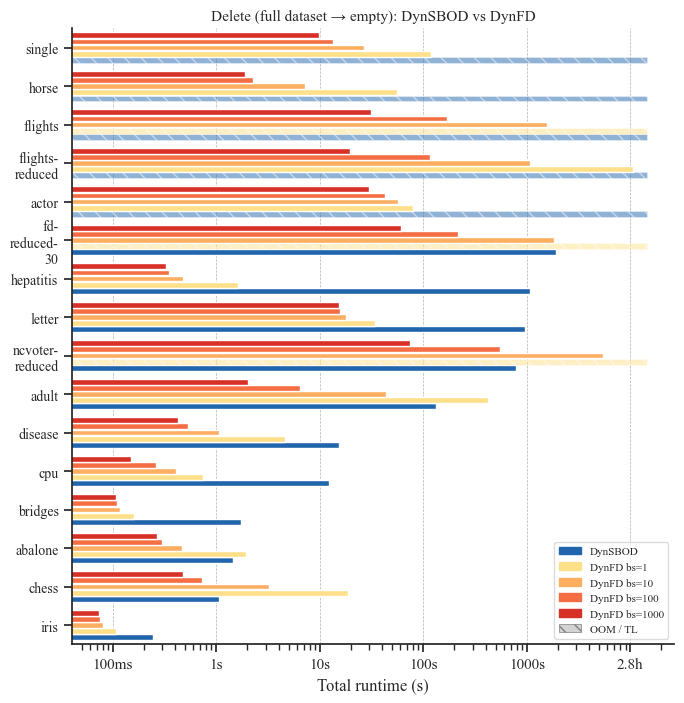


Filtered from DELETE chart (2 dataset(s)):
  ncvoter                                   reason=DynFD not run / only OOM  sbod=oom  dynfd=[bs=1:oom, bs=10:oom, bs=100:oom, bs=1000:oom]
  plista                                    reason=DynFD not run / only OOM  sbod=oom  dynfd=[bs=1:oom, bs=10:oom, bs=100:oom, bs=1000:oom]


In [6]:
delete_rows = []
filtered_delete = []   # (ident, reason, sbod_status, dynfd_statuses)

for combo_key in sorted(sbod_delete):
    if not combo_key.startswith("algo0_java0_"):
        continue
    ident = combo_key[len("algo0_java0_"):]
    if any(x in ident for x in ("_second_half_delete", "_first_half")):
        continue

    if is_excluded(ident):
        continue

    sbod_st, sbod_ms = sbod_run_status(sbod_delete, combo_key)
    if sbod_st == "missing":
        filtered_delete.append((display_name(ident), "SBOD data missing", sbod_st, {}))
        continue

    fd_key = to_dynfd_key(ident)

    # Omit datasets where DynFD was never attempted at all
    if not dynfd_has_any_data(fd_key, "delete"):
        fd_st_f = {bs: dynfd_batch_status(fd_key, bs, "delete")[0] for bs in BATCH_SIZES}
        filtered_delete.append((display_name(ident), "DynFD not run / only OOM", sbod_st, fd_st_f))
        continue

    fd_statuses = {bs: dynfd_batch_status(fd_key, bs, "delete")[0] for bs in BATCH_SIZES}
    fd_times    = {bs: dynfd_batch_status(fd_key, bs, "delete")[1] for bs in BATCH_SIZES}

    delete_rows.append(dict(
        label        = display_name(ident),
        sbod_ms      = sbod_ms,
        sbod_ms_err  = sbod_run_std(sbod_delete, combo_key),
        sbod_status  = sbod_st,
        dynfd_ms     = fd_times,
        dynfd_ms_err = {bs: dynfd_batch_std(fd_key, bs, "delete") for bs in BATCH_SIZES},
        dynfd_status = fd_statuses,
    ))

delete_rows.sort(key=lambda r: r["sbod_ms"] if r["sbod_ms"] is not None else float("inf"))

grouped_bar(
    delete_rows,
    ylabel    = "Total runtime (s)",
    title     = "Delete (full dataset → empty): DynSBOD vs DynFD",
    save_name = "comparison_delete",
    ylog      = True,
)

if filtered_delete:
    print(f"\nFiltered from DELETE chart ({len(filtered_delete)} dataset(s)):")
    for name, reason, ss, fds in sorted(filtered_delete):
        fd_summary = ", ".join(f"bs={bs}:{s}" for bs, s in fds.items()) if fds else "n/a"
        print(f"  {name:40s}  reason={reason}  sbod={ss}  dynfd=[{fd_summary}]")
else:

    print("\nNo datasets filtered from DELETE chart.")

## Chart 2b: Combined Insert + Delete (shared dataset axis)

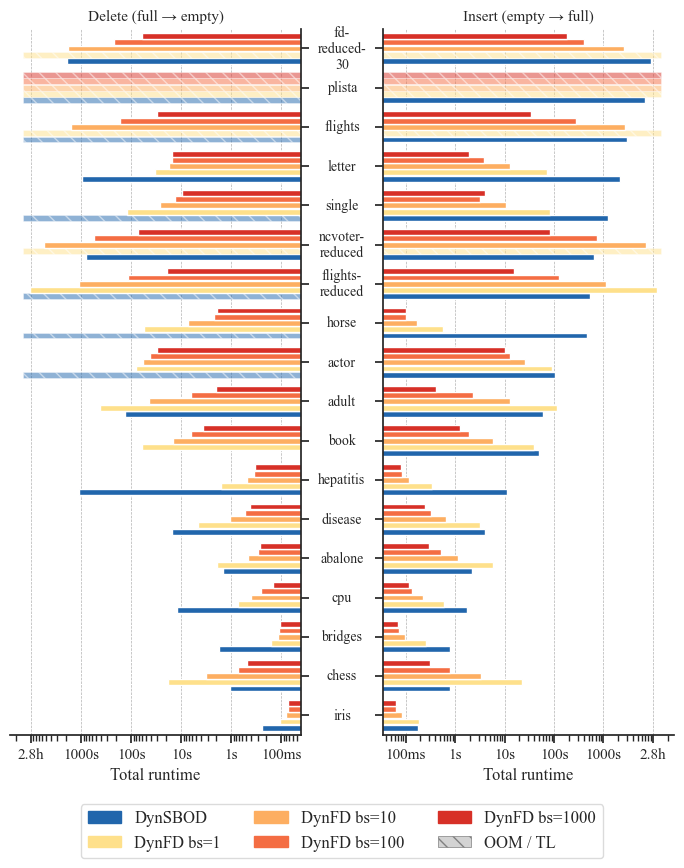

In [7]:
# Build a supplemented delete list for the combined chart:
# include any dataset from insert_rows that is absent from delete_rows
# as long as DynFD was at least attempted (even OOM) on the delete side.
delete_labels_set = {r["label"] for r in delete_rows}
delete_rows_combined = list(delete_rows)

for ins_row in insert_rows:
    lbl = ins_row["label"]
    if lbl in delete_labels_set:
        continue
    # Reverse the display name back to an identifier that to_dynfd_key understands.
    # insert rows were built from sbod_insert keys; find the matching key.
    ident = next(
        (k[len("algo0_java0_"):] for k in sbod_insert
         if k.startswith("algo0_java0_") and display_name(k[len("algo0_java0_"):]) == lbl),
        None,
    )
    if ident is None:
        continue
    fd_key = to_dynfd_key(ident)
    fd_statuses_d = {bs: dynfd_batch_status(fd_key, bs, "delete")[0] for bs in BATCH_SIZES}
    # Include only if DynFD was actually attempted (any status other than 'missing')
    if all(s == "missing" for s in fd_statuses_d.values()):
        continue
    fd_times_d = {bs: dynfd_batch_status(fd_key, bs, "delete")[1] for bs in BATCH_SIZES}
    sbod_st_d, sbod_ms_d = sbod_run_status(sbod_delete, f"algo0_java0_{ident}")
    delete_rows_combined.append(dict(
        label        = lbl,
        sbod_ms      = sbod_ms_d,
        sbod_ms_err  = sbod_run_std(sbod_delete, f"algo0_java0_{ident}"),
        sbod_status  = sbod_st_d,
        dynfd_ms     = fd_times_d,
        dynfd_ms_err = {bs: dynfd_batch_std(fd_key, bs, "delete") for bs in BATCH_SIZES},
        dynfd_status = fd_statuses_d,
    ))

grouped_bar_combined(
    insert_rows,
    delete_rows_combined,
    ylabel    = "Total runtime",
    save_name = "comparison_insert_delete_combined",
    ylog      = True,
)


In [8]:
## Chart 3: Dynamic (wikipedia insert/delete/update events)

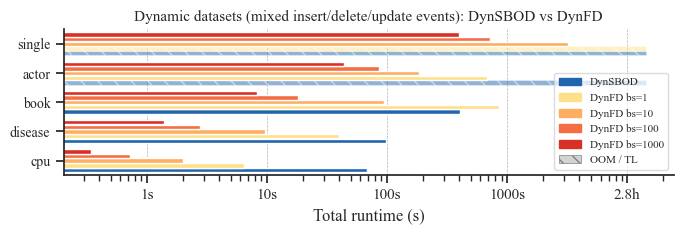


No datasets filtered from DYNAMIC chart.


In [9]:
dyn_rows = []
filtered_dynamic = []   # (ident, reason, sbod_status, dynfd_statuses)

for combo_key in sorted(sbod_dynamic):
    if not combo_key.startswith("algo0_java0_"):
        continue
    ident = combo_key[len("algo0_java0_"):]

    if is_excluded(ident):
        continue

    sbod_st, sbod_ms = sbod_run_status(sbod_dynamic, combo_key)
    fd_key  = to_dynfd_key(ident)

    # Omit datasets where DynFD was never attempted at all
    if not dynfd_has_any_data(fd_key, "dynamic"):
        fd_st_f = {bs: dynfd_batch_status(fd_key, bs, "dynamic")[0] for bs in BATCH_SIZES}
        filtered_dynamic.append((display_name(ident), "DynFD not run / only OOM", sbod_st, fd_st_f))
        continue

    fd_statuses = {bs: dynfd_batch_status(fd_key, bs, "dynamic")[0] for bs in BATCH_SIZES}
    fd_times    = {bs: dynfd_batch_status(fd_key, bs, "dynamic")[1] for bs in BATCH_SIZES}

    if sbod_st == "missing" and all(s == "missing" for s in fd_statuses.values()):
        filtered_dynamic.append((display_name(ident), "all data missing", sbod_st, fd_statuses))
        continue

    dyn_rows.append(dict(
        label        = display_name(ident),
        sbod_ms      = sbod_ms,
        sbod_ms_err  = sbod_run_std(sbod_dynamic, combo_key),
        sbod_status  = sbod_st,
        dynfd_ms     = fd_times,
        dynfd_ms_err = {bs: dynfd_batch_std(fd_key, bs, "dynamic") for bs in BATCH_SIZES},
        dynfd_status = fd_statuses,
    ))

# Add DynFD-only entries (wikipedia_dynamic datasets not covered by DynSBOD)
sbod_dyn_idents = {
    display_name(k[len("algo0_java0_"):])
    for k in sbod_dynamic if k.startswith("algo0_java0_")
}
for fd_full_key in sorted(dynfd):
    if not fd_full_key.startswith("wikipedia_dynamic_"):
        continue
    folder = fd_full_key[len("wikipedia_dynamic_"):]
    if is_excluded(folder):
        continue
    if folder in sbod_dyn_idents:
        continue
    fd_statuses = {bs: dynfd_batch_status(fd_full_key, bs, "dynamic")[0] for bs in BATCH_SIZES}
    fd_times    = {bs: dynfd_batch_status(fd_full_key, bs, "dynamic")[1] for bs in BATCH_SIZES}
    if all(s == "missing" for s in fd_statuses.values()):
        filtered_dynamic.append((folder, "DynFD-only: all data missing", "n/a", fd_statuses))
        continue
    dyn_rows.append(dict(
        label        = folder,
        sbod_ms      = None,
        dynfd_ms     = fd_times,
        dynfd_status = fd_statuses,
    ))

dyn_rows.sort(key=lambda r: r["sbod_ms"] if r["sbod_ms"] is not None else float("inf"))

grouped_bar(
    dyn_rows,
    ylabel    = "Total runtime (s)",
    title     = "Dynamic datasets (mixed insert/delete/update events): DynSBOD vs DynFD",
    save_name = "comparison_dynamic",
    ylog      = True,
)

if filtered_dynamic:
    print(f"\nFiltered from DYNAMIC chart ({len(filtered_dynamic)} dataset(s)):")
    for name, reason, ss, fds in sorted(filtered_dynamic):
        fd_summary = ", ".join(f"bs={bs}:{s}" for bs, s in fds.items()) if fds else "n/a"
        print(f"  {name:40s}  reason={reason}  sbod={ss}  dynfd=[{fd_summary}]")
else:

    print("\nNo datasets filtered from DYNAMIC chart.")